<a href="https://colab.research.google.com/github/YRMESHRAM/Machine-Vision-Practical/blob/main/MV_P5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Install OpenCV
!pip install opencv-python

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile

In [23]:
import os
import kagglehub

print("Downloading dataset...")
# 'path' will now hold the root directory of the extracted dataset from kagglehub
path = kagglehub.dataset_download("zerghamwarraich1/yale-images-dataset-for-image-classifications")
print(f"Dataset downloaded and extracted to: {path}")

# Set the extract_dir to the path provided by kagglehub, as it's already extracted.
extract_dir = path # Now extract_dir is the actual location of the dataset files

print("Contents of extracted directory:")
# List contents of the dataset root to confirm its structure
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')
    # Optionally, limit the output for very large datasets
    if level > 2: # Stop after 3 levels deep to avoid excessive output
        break


Using Colab cache for faster access to the 'yale-images-dataset-for-image-classifications' dataset.
Dataset downloaded and extracted to: /kaggle/input/yale-images-dataset-for-image-classifications
Contents of extracted directory:
yale-images-dataset-for-image-classifications/
    yalefaces/
        subject05.surprised
        subject09.normal
        subject04.rightlight
        subject03.leftlight
        subject07.glasses
        subject03.normal
        subject11.rightlight
        subject02.surprised
        subject14.surprised
        subject12.centerlight
        subject01.sad
        subject09.glasses
        subject01.rightlight
        subject03.noglasses
        subject06.noglasses
        subject09.happy
        subject03.centerlight
        subject12.surprised
        subject15.surprised
        subject15.happy
        subject13.happy
        subject04.wink
        subject08.leftlight
        subject12.glasses
        subject12.rightlight
        subject13.centerlight
     

In [17]:
# Define paths for Haar Cascade files
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
eyes_cascade_path = cv2.data.haarcascades + 'haarcascade_eye.xml'

# Check if the files exist
if not os.path.exists(face_cascade_path):
    print(f"Error: Face cascade file not found at {face_cascade_path}")
if not os.path.exists(eyes_cascade_path):
    print(f"Error: Eye cascade file not found at {eyes_cascade_path}")

In [18]:
# Load the cascade classifiers
face_cascade = cv2.CascadeClassifier(face_cascade_path)
eyes_cascade = cv2.CascadeClassifier(eyes_cascade_path)

print("Haar Cascade classifiers loaded.")

Haar Cascade classifiers loaded.


In [26]:
def detect_faces_and_eyes(image_path):
    # Read the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, 0, 0

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    num_faces = len(faces)
    num_eyes = 0

    for (x, y, w, h) in faces:
        # Draw rectangle around the face
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Region of Interest for eyes (inside the face rectangle)
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = img[y:y + h, x:x + w]

        # Detect eyes within the face region
        eyes = eyes_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=5, minSize=(15, 15))

        num_eyes += len(eyes)

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    # Convert BGR to RGB for displaying with matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb, num_faces, num_eyes

Using sample image: /kaggle/input/yale-images-dataset-for-image-classifications/yalefaces/subject01.glasses.gif


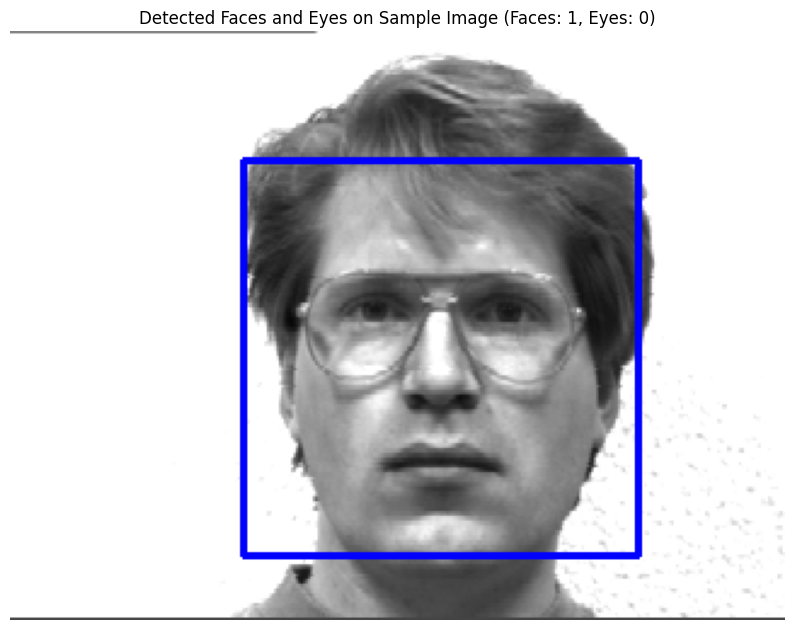

Detected 1 face(s) and 0 eye(s).


In [27]:
# List all files in the extracted directory to find a sample image
# The structure of the downloaded dataset is 'dataset_root/yalefaces/'
dataset_base_path = os.path.join(extract_dir, 'yalefaces')

# Find the first image file for demonstration
sample_image_path = None
for root, dirs, files in os.walk(dataset_base_path):
    for file in files:
        # Ensure we pick actual image files and not auxiliary files like Readme.txt or .gif (which seem to be present)
        # Updated to include .gif and .pgm which are common for Yale Faces dataset
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.pgm')):
            # Also, exclude the special 'subject01.gif' if it's just a placeholder or not a standard face image
            # Based on common Yale datasets, images like 'subjectXX.expression' are actual images.
            if file.lower() != 'subject01.gif': # Exclude generic gif if it's not a real face image
                sample_image_path = os.path.join(root, file)
                break
    if sample_image_path: # Found an image, break outer loop
        break

if sample_image_path:
    print(f"Using sample image: {sample_image_path}")
    detected_image, num_faces, num_eyes = detect_faces_and_eyes(sample_image_path)

    if detected_image is not None:
        plt.figure(figsize=(10, 8))
        plt.imshow(detected_image)
        plt.title(f'Detected Faces and Eyes on Sample Image (Faces: {num_faces}, Eyes: {num_eyes})')
        plt.axis('off')
        plt.show()
        print(f"Detected {num_faces} face(s) and {num_eyes} eye(s).")
else:
    print(f"No suitable image files found in {dataset_base_path}")

Evaluating lighting conditions for: /kaggle/input/yale-images-dataset-for-image-classifications/yalefaces/subject01.glasses.gif
For 'Darker (beta=-75)': Detected 1 face(s) and 0 eye(s).
For 'Original Brightness (beta=0)': Detected 1 face(s) and 0 eye(s).
For 'Brighter (beta=75)': Detected 1 face(s) and 0 eye(s).
For 'Much Brighter (beta=150)': Detected 1 face(s) and 0 eye(s).


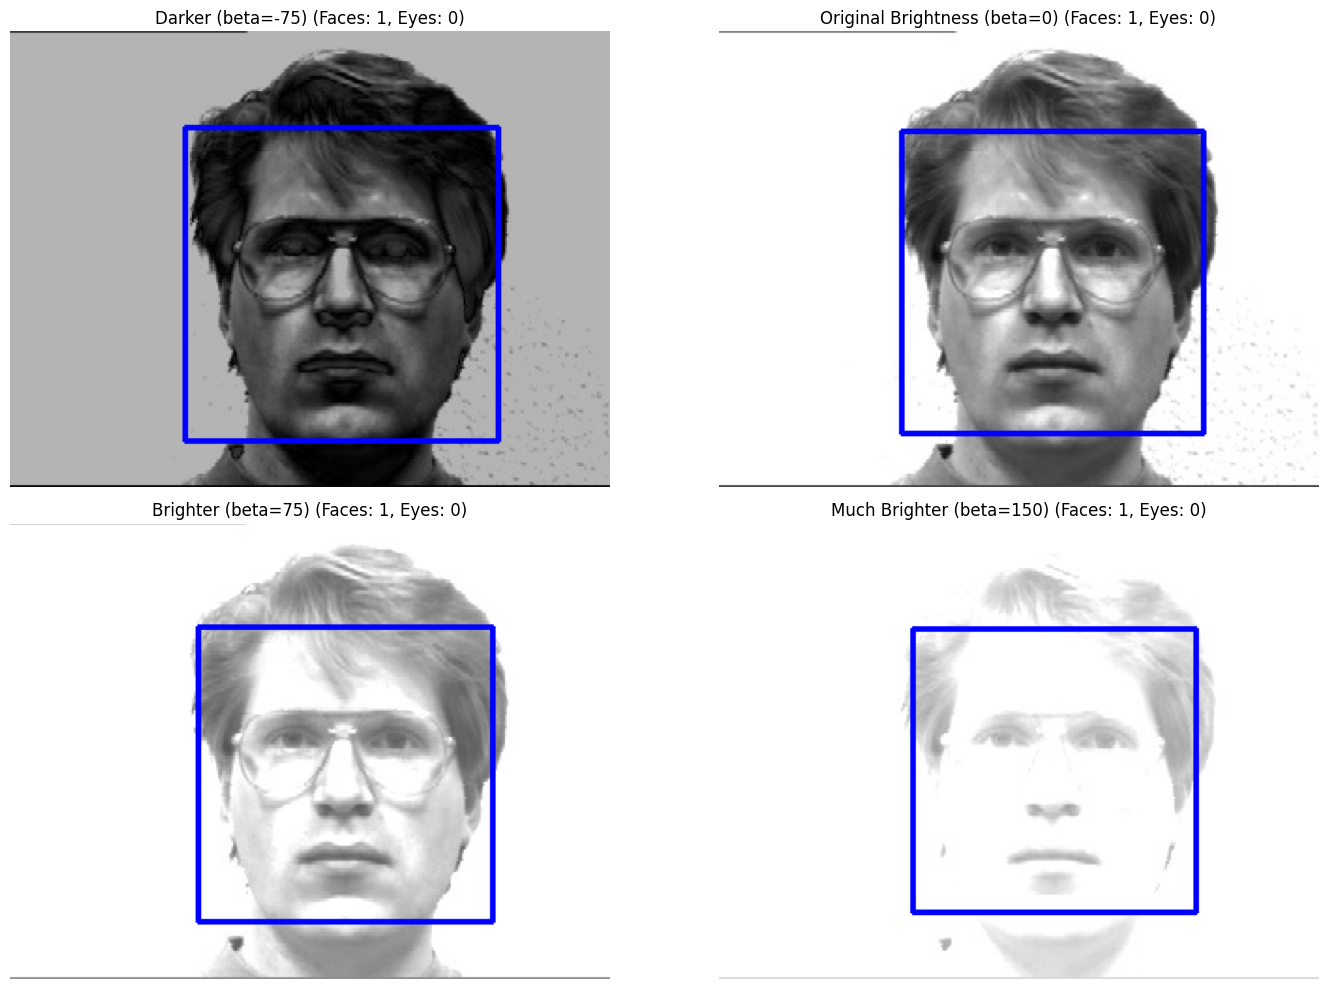

In [28]:
def adjust_brightness(image, beta_value=0):
    # beta_value is the brightness control (typically -100 to 100 or higher/lower).
    # We convert to float to prevent overflow issues before converting back to uint8.
    # cv2.convertScaleAbs handles clipping values to 0-255.
    adjusted = cv2.convertScaleAbs(image, beta=beta_value)
    return adjusted

def evaluate_lighting_conditions(image_path):
    original_img = cv2.imread(image_path)

    if original_img is None:
        print(f"Error: Could not load image from {image_path}. Please ensure a valid image exists.")
        return

    # Convert original to RGB for consistent display
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Define brightness levels to test (beta values for adjust_brightness)
    # These values are added to pixel intensity, so negative makes it darker, positive brighter.
    brightness_levels = [-75, 0, 75, 150] # Darker, Original, Brighter, Much Brighter
    titles = ['Darker (beta=-75)', 'Original Brightness (beta=0)', 'Brighter (beta=75)', 'Much Brighter (beta=150)']

    plt.figure(figsize=(15, 10))

    for i, beta in enumerate(brightness_levels):
        # Apply brightness adjustment
        adjusted_img_bgr = adjust_brightness(original_img, beta_value=beta)
        adjusted_img_rgb = cv2.cvtColor(adjusted_img_bgr, cv2.COLOR_BGR2RGB)

        # Temporarily save the adjusted image to a unique path for detection, then delete.
        # This is because detect_faces_and_eyes expects a path.
        temp_image_path = f"temp_image_beta_{beta}.jpg"
        cv2.imwrite(temp_image_path, adjusted_img_bgr)

        detected_on_current_img, num_faces, num_eyes = detect_faces_and_eyes(temp_image_path)

        if detected_on_current_img is not None:
            plt.subplot(2, 2, i + 1)
            plt.imshow(detected_on_current_img)
            plt.title(f'{titles[i]} (Faces: {num_faces}, Eyes: {num_eyes})')
            plt.axis('off')
            print(f"For '{titles[i]}': Detected {num_faces} face(s) and {num_eyes} eye(s).")

        # Clean up the temporary file
        os.remove(temp_image_path)

    plt.tight_layout()
    plt.show()

# Use the same sample_image_path that was successfully detected before
# Ensure 'sample_image_path' is defined from previous steps
if 'sample_image_path' in locals() and sample_image_path is not None:
    print(f"Evaluating lighting conditions for: {sample_image_path}")
    evaluate_lighting_conditions(sample_image_path)
else:
    print("Error: sample_image_path is not defined. Please ensure a sample image was successfully loaded in previous steps.")
